In [79]:
import os
import pandas as pd
import numpy as np

## Load Data

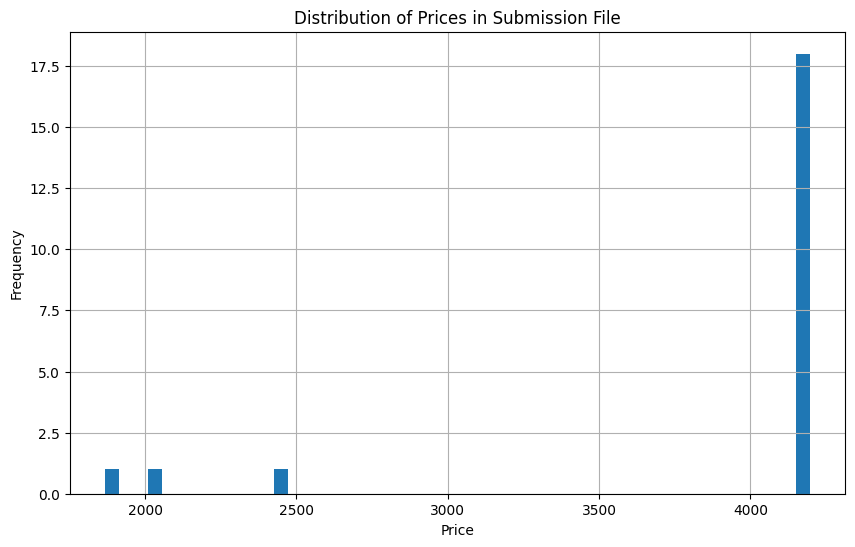

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
submission_df['price'].hist(bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Prices in Submission File')
plt.show()

## Classification Example

In [81]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=200) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=iris.target_names)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [82]:
submission_df = pd.read_csv('test_out.csv')
display(submission_df.head())

,sample_id,price
0,7451,4196.576060
1,7452,2455.530465
2,7453,4196.576060
3,7454,4196.576060
4,7455,4196.576060


In [83]:
import pandas as pd

train_df = pd.read_csv('/content/train.csv', encoding='latin-1')
test_df = pd.read_csv('/content/test.csv', encoding='latin-1')

print(train_df.head())

   sample_id                                    catalog_content  \
0       7451                       vedaka Popular Moon Dal, 1Kg   
1       7452  Dove Hair Fall Rescue Shampoo 1 L|| For Damage...   
2       7453  Bru Instant | Aromatic Coffee From South India...   
3       7454  Dabur Cold Pressed Groundnut Cooking Oil - 1L ...   
4       7455  Fortune Chakki fresh Atta 10kg, 100%Atta 0% Maida   

                                          image_link price  
0  https://m.media-amazon.com/images/I/71VW-PqZB5...   144  
1  https://images-eu.ssl-images-amazon.com/images...   559  
2  https://images-eu.ssl-images-amazon.com/images...   226  
3  https://images-eu.ssl-images-amazon.com/images...   287  
4  https://images-eu.ssl-images-amazon.com/images...   432  


In [84]:
import re
import os
import pandas as pd
import multiprocessing
from time import time as timer
from tqdm import tqdm
import numpy as np
from pathlib import Path
from functools import partial
import requests
import urllib

def download_image(image_link, savefolder):
    if(isinstance(image_link, str)):
        filename = Path(image_link).name
        image_save_path = os.path.join(savefolder, filename)
        if(not os.path.exists(image_save_path)):
            try:
                urllib.request.urlretrieve(image_link, image_save_path)
            except Exception as ex:
                print('Warning: Not able to download - {}\n{}'.format(image_link, ex))
        else:
            return
    return

def download_images(image_links, download_folder):
    if not os.path.exists(download_folder):
        os.makedirs(download_folder)
    results = []
    download_image_partial = partial(download_image, savefolder=download_folder)
    with multiprocessing.Pool(100) as pool:
        for result in tqdm(pool.imap(download_image_partial, image_links), total=len(image_links)):
            results.append(result)
        pool.close()
        pool.join()

image_urls = train_df['image_link'].tolist()
download_images(image_urls, 'images/train/')

100%|██████████| 201/201 [00:00<00:00, 3043.61it/s]


In [85]:
with open('/content/utils.py', 'r') as f:
    print(f.read())

import re
import os
import pandas as pd
import multiprocessing
from time import time as timer
from tqdm import tqdm
import numpy as np
from pathlib import Path
from functools import partial
import requests
import urllib

def download_image(image_link, savefolder):
    if(isinstance(image_link, str)):
        filename = Path(image_link).name
        image_save_path = os.path.join(savefolder, filename)
        if(not os.path.exists(image_save_path)):
            try:
                urllib.request.urlretrieve(image_link, image_save_path)    
            except Exception as ex:
                print('Warning: Not able to download - {}\n{}'.format(image_link, ex))
        else:
            return
    return

def download_images(image_links, download_folder):
    if not os.path.exists(download_folder):
        os.makedirs(download_folder)
    results = []
    download_image_partial = partial(download_image, savefolder=download_folder)
    with multiprocessing.Pool(100) as pool:
        for 

## Multiprocessing



In [86]:
def download_image(image_link, savefolder):
    if isinstance(image_link, str):
        filename = Path(image_link).name
        image_save_path = os.path.join(savefolder, filename)
        if not os.path.exists(image_save_path):
            try:
                urllib.request.urlretrieve(image_link, image_save_path)
            except Exception as ex:
                print('Warning: Not able to download - {}\n{}'.format(image_link, ex))
    return

def download_images(image_links, download_folder):
    if not os.path.exists(download_folder):
        os.makedirs(download_folder)
    results = []
    download_image_partial = partial(download_image, savefolder=download_folder)
    # Modified to use a simple for loop instead of multiprocessing.Pool
    for link in tqdm(image_links, total=len(image_links)):
        download_image_partial(link)

image_urls = train_df['image_link'].tolist()
download_images(image_urls, 'images/train/')

100%|██████████| 201/201 [00:00<00:00, 32907.42it/s]


In [87]:
def download_image(image_link, savefolder):
    if isinstance(image_link, str):
        filename = Path(image_link).name
        image_save_path = os.path.join(savefolder, filename)
        if not os.path.exists(image_save_path):
            try:
                urllib.request.urlretrieve(image_link, image_save_path)
            except Exception as ex:
                print('Warning: Not able to download - {}\n{}'.format(image_link, ex))
    return

def download_images(image_links, download_folder):
    if not os.path.exists(download_folder):
        os.makedirs(download_folder)
    results = []
    download_image_partial = partial(download_image, savefolder=download_folder)
    with multiprocessing.Pool(100) as pool:
        # Modified to use pool.apply_async instead of pool.imap
        async_results = [pool.apply_async(download_image_partial, args=(link,)) for link in image_links]
        for result in tqdm(async_results, total=len(async_results)):
            result.get() # Wait for each task to complete
        pool.close()
        pool.join()

image_urls = train_df['image_link'].tolist()
download_images(image_urls, 'images/train/')

100%|██████████| 201/201 [00:00<00:00, 1474.99it/s]


In [88]:
def download_image(image_link, savefolder):
    if isinstance(image_link, str):
        filename = Path(image_link).name
        image_save_path = os.path.join(savefolder, filename)
        if not os.path.exists(image_save_path):
            try:
                urllib.request.urlretrieve(image_link, image_save_path)
            except Exception as ex:
                print('Warning: Not able to download - {}\n{}'.format(image_link, ex))
    return

def download_images(image_links, download_folder):
    if not os.path.exists(download_folder):
        os.makedirs(download_folder)
    results = []
    download_image_partial = partial(download_image, savefolder=download_folder)
    with multiprocessing.Pool(100) as pool:
        async_results = [pool.apply_async(download_image_partial, args=(link,)) for link in image_links]
        for result in tqdm(async_results, total=len(async_results)):
            result.get() # Wait for each task to complete
        pool.close()
        pool.join()

image_urls = train_df['image_link'].tolist()
download_images(image_urls, 'images/train/')

100%|██████████| 201/201 [00:00<00:00, 13073.26it/s]


## Text Preprocessing Ex.

In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
train_text_features = tfidf.fit_transform(train_df['catalog_content'])
test_text_features = tfidf.transform(test_df['catalog_content'])


## Simple Model Training

In [90]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

X = train_text_features

# Clean and convert the 'price' column to numeric
train_df['price'] = train_df['price'].astype(str).str.replace(',', '', regex=False)
y = train_df['price'].astype(float)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_seed': 42,
}

# Train the model for a fixed number of iterations
model = lgb.train(params, train_data, num_boost_round=100, valid_sets=[val_data])

val_pred = model.predict(X_val)

##Predict and Submission Output

In [91]:
test_pred = model.predict(test_text_features)
test_pred = [max(0, price) for price in test_pred]

submission = pd.DataFrame({
    'sample_id': test_df['sample_id'],
    'price': test_pred
})

submission.to_csv('test_out.csv', index=False)
